# Bias Analysis - Credit Application Dataset

## Introduction

This notebook investigates potential bias in NovaCred’s historical credit decisions. 
The objective is to evaluate whether demographic attributes such as **gender** or **age** influence loan approval outcomes.

We begin by preparing the dataset and ensuring that relevant attributes are standardized. 
In particular, gender labels must be consistent and the applicant’s **age is derived from the date of birth field**.

Once the dataset is prepared, we conduct several fairness analyses:

1. **Disparate Impact Analysis (Gender)** – evaluating whether approval rates differ significantly between male and female applicants using the four-fifths rule.
2. **Age-Based Bias Analysis** – examining approval patterns across age groups.
3. **Proxy Discrimination Analysis** – investigating whether variables such as ZIP code indirectly capture protected characteristics.
4. **Interaction Effects** – exploring whether combinations of attributes (e.g., age and gender) produce systematic differences in approval outcomes.

These analyses aim to identify potential algorithmic bias in the lending process and assess whether the system may produce discriminatory outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_bias = pd.read_json("../data/processed/cleaned_credit_applications.json", orient="records")


----
## Data Preparation and Validation for Bias Analysis

Before performing fairness analysis, we verify that key attributes used in the
analysis are correctly formatted and contain expected values.

The following checks are performed:

- Validate that the **gender column contains only expected categories**
- Convert **date of birth to datetime format** and derive the applicant's age

These validation steps ensure that the fairness analysis is based on
well-defined and reliable variables.


In [2]:
# Create working dataset

print("===== BIAS ANALYSIS DATA CHECKS =====\n")

# 1. Gender validation
print("Gender value counts:")
print(df_bias['applicant_info.gender'].value_counts(dropna=False))

print("\nUnique gender values:")
print(df_bias['applicant_info.gender'].unique())


# 2. Date of birth format
print("\nChecking DOB format...")

df_bias['applicant_info.date_of_birth'] = pd.to_datetime(
    df_bias['applicant_info.date_of_birth'], errors='coerce'
)

invalid_dob = df_bias['applicant_info.date_of_birth'].isna().sum()

print("Invalid DOB values:", invalid_dob)


# 3. Age calculation check
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

print("\nAge summary:")
print(df_bias['age'].describe())


# 4. Approval variable
print("\nLoan approval distribution:")
print(df_bias['decision.loan_approved'].value_counts())


# 5. Missing values in key fields
print("\nMissing values in key analysis columns:")

cols_to_check = [
    'applicant_info.gender',
    'applicant_info.date_of_birth',
    'decision.loan_approved'
]

print(df_bias[cols_to_check].isnull().sum())

===== BIAS ANALYSIS DATA CHECKS =====

Gender value counts:
applicant_info.gender
Female    251
Male      247
            2
Name: count, dtype: int64

Unique gender values:
['Male' 'Female' '']

Checking DOB format...
Invalid DOB values: 4

Age summary:
count    496.000000
mean      40.772177
std       10.958808
min       23.000000
25%       32.000000
50%       39.000000
75%       47.000000
max       67.000000
Name: age, dtype: float64

Loan approval distribution:
decision.loan_approved
True     292
False    208
Name: count, dtype: int64

Missing values in key analysis columns:
applicant_info.gender           0
applicant_info.date_of_birth    4
decision.loan_approved          0
dtype: int64


The diagnostic checks reveal two minor data issues that must be addressed before conducting fairness analysis.

First, two records contain empty values in the gender field. Since disparate impact analysis requires clearly defined demographic groups, these records cannot be reliably assigned to either group and will be excluded from the gender fairness analysis.
Second, four records contain invalid or missing birthdates, which prevents age calculation. These records will be excluded from analyses involving age.

In [3]:
# --- Fix gender issue ---
df_bias['applicant_info.gender'] = df_bias['applicant_info.gender'].replace('', 'Unknown')

# Remove records with unknown gender for fairness analysis
df_bias = df_bias[df_bias['applicant_info.gender'].isin(['Male', 'Female'])]

# --- Remove rows with invalid DOB (needed for age analysis) ---
df_bias = df_bias[df_bias['applicant_info.date_of_birth'].notna()]

# Recalculate age to ensure consistency
today = pd.Timestamp.today()
df_bias['age'] = (today - df_bias['applicant_info.date_of_birth']).dt.days // 365

# Create approval indicator
df_bias['approved'] = df_bias['decision.loan_approved']

# Final dataset check
print("Final dataset size:", len(df_bias))
print(df_bias['applicant_info.gender'].value_counts())

Final dataset size: 495
applicant_info.gender
Female    249
Male      246
Name: count, dtype: int64


------


## Gender Disparate Impact Analysis

Credit approval systems must be evaluated for potential discrimination against protected groups. 
One commonly used fairness metric is the **Disparate Impact (DI) ratio**, which compares the 
approval rate of an unprivileged group to that of a privileged group. According to the **four-fifths rule**, a DI ratio below **0.8** indicates potential 
disparate impact and may suggest discriminatory decision patterns.

In [10]:
approval_summary = df_bias.groupby('applicant_info.gender').agg(
    applicants=('approved', 'count'),
    approved=('approved', 'sum')
)

approval_summary['approval_rate'] = approval_summary['approved'] / approval_summary['applicants']

approval_summary

,applicants,approved,approval_rate
applicant_info.gender,,,
Female,249,126,0.506024
Male,246,162,0.658537


The results show that male applicants have a higher approval rate than female applicants. Therefore, male applicants are treated as the **privileged group**, while female applicants represent the **unprivileged group** for the purpose of the disparate impact analysis.

The next step is to compute the Disparate Impact ratio.


Disparate Impact Ratio: 0.7684069611780454


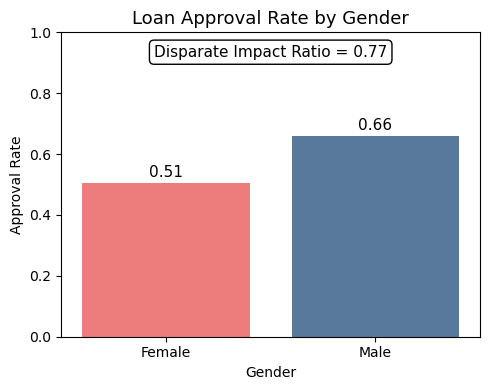

In [20]:
# Extract approval rates from summary table
female_rate = approval_summary.loc['Female', 'approval_rate']
male_rate = approval_summary.loc['Male', 'approval_rate']

# Compute Disparate Impact
di_ratio = female_rate / male_rate

print("\nDisparate Impact Ratio:", di_ratio)


# Plot approval rate by gender
plt.figure(figsize=(5,4))

sns.barplot(
    x=approval_summary.index,
    y=approval_summary['approval_rate'],
    palette=["#FF6B6B", "#4E79A7"]
)

plt.title("Loan Approval Rate by Gender", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add approval rate labels above bars
for i, v in enumerate(approval_summary['approval_rate']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11)

# Add DI ratio annotation
plt.text(
    0.5, 0.92,
    f"Disparate Impact Ratio = {di_ratio:.2f}",
    ha='center',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round')
)

plt.tight_layout()
plt.show()

The **Disparate Impact ratio is 0.77**, meaning female applicants are approved at
**77% of the rate of male applicants**. Because this value is below the **0.8 threshold**
commonly used in fairness audits, it suggests potential gender disparity in lending decisions.

A **Chi-Square test** is then used to assess whether the observed difference is
statistically significant or could be explained by random variation.

In [21]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df_bias['applicant_info.gender'],
    df_bias['approved']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 11.211547625416834
p-value: 0.0008128989785515727


The Chi-Square test produces a **p-value of 0.0008**, which is well below the
significance threshold of **0.05**. This means we reject the null hypothesis
that loan approval decisions are independent of gender.

In other words, the difference in approval rates between male and female
applicants is **statistically significant**, suggesting that gender is
associated with loan approval outcomes.

-----
## Age-Based Bias Analysis

In addition to gender, we analyze whether loan approval outcomes vary
across different age groups.

Age is derived from the applicant's date of birth and applicants are
grouped into age ranges to compare approval rates across groups. This
helps identify whether the model produces systematically different
approval outcomes for younger or older applicants.

In [ ]:
# Create age groups
bins = [18, 25, 35, 50, 65, 100]
labels = ['18–25', '26–35', '36–50', '51–65', '65+']

df_bias['age_group'] = pd.cut(df_bias['age'], bins=bins, labels=labels)

# Approval rate by age group
age_approval_rates = df_bias.groupby('age_group')['decision.loan_approved'].mean()

print(age_approval_rates)

# Plotting graph
plt.figure(figsize=(7,4))

sns.barplot(
    x=age_approval_rates.index,
    y=age_approval_rates.values,
    palette="viridis"
)

plt.title("Loan Approval Rate by Age Group", fontsize=13)
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

# Add labels
for i, v in enumerate(age_approval_rates.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

The visualization shows variation in approval rates across age groups.
Applicants aged **36–50** exhibit the highest approval rate, while
younger applicants (18–35) have lower approval rates.

These differences may reflect how the credit decision algorithm weighs
financial attributes correlated with age, such as income levels,
employment stability, or credit history length.

In [ ]:
# Create contingency table
age_table = pd.crosstab(
    df_bias['age_group'],
    df_bias['decision.loan_approved']
)

print("Contingency table:")
print(age_table)

# Chi-square test
chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print("\nChi-square statistic:", chi2_age)
print("p-value:", p_age)

-----
## Proxy Discrimination Analysis

In addition to direct demographic attributes such as gender or age,
machine learning models may produce biased outcomes through **proxy
variables**. A proxy variable is a non-protected attribute that is
correlated with protected characteristics and can indirectly transmit
demographic patterns into model decisions.

A common example in credit decision systems is **ZIP code**, which
represents geographic areas that may differ in demographic composition
or socioeconomic characteristics.

In this section, we investigate whether ZIP code could act as a proxy
variable by analyzing:

1. Whether approval outcomes vary across ZIP codes.
2. Whether ZIP codes are associated with demographic characteristics
   such as gender and age.
3. Whether key numerical features correlate with loan approval outcomes.

If ZIP code is associated with both demographic characteristics and
approval outcomes, it may indirectly transmit demographic disparities
into the model's decisions.

### Applications per ZIP Code

Before analyzing approval rates across ZIP codes, we examine the number
of applications per geographic area. Some ZIP codes may appear only a
few times in the dataset, which can produce unstable approval rates.

To ensure meaningful comparisons, we focus on ZIP codes with at least
five applications.

In [ ]:
zip_counts = df_bias['applicant_info.zip_code'].value_counts()

print("Applications per ZIP code:")
print(zip_counts.head(10))

Because many ZIP codes appear only a few times in the dataset, approval
rates could become artificially extreme (for example 0% or 100%). To ensure
more stable comparisons, we restrict the analysis to ZIP codes with at
least five applications.

In [ ]:
valid_zips = zip_counts[zip_counts >= 5].index

df_zip_filtered = df_bias[
    df_bias['applicant_info.zip_code'].isin(valid_zips)
]

In [ ]:
zip_approval = df_zip_filtered.groupby(
    'applicant_info.zip_code'
)['decision.loan_approved'].mean()

zip_approval = zip_approval.sort_values()


plt.figure(figsize=(10,4))

sns.barplot(
    x=zip_approval.index.astype(str),
    y=zip_approval.values,
    palette="viridis"
)

plt.title("Loan Approval Rate by ZIP Code (ZIPs with ≥5 Applications)")
plt.xlabel("ZIP Code")
plt.ylabel("Approval Rate")

plt.ylim(0,1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Relationship Between ZIP Code and Loan Approval

To assess whether geographic location influences model outcomes, we
analyze loan approval rates across ZIP codes.

If approval outcomes vary significantly across locations, this may
indicate that geographic attributes influence the model’s decisions.

In [ ]:
zip_approval_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['decision.loan_approved']
)

print(zip_approval_table)

In [ ]:
from scipy.stats import chi2_contingency

chi2_zip_approval, p_zip_approval, dof, expected = chi2_contingency(zip_approval_table)

print("Chi-square statistic:", chi2_zip_approval)
print("p-value:", p_zip_approval)

With a p-value of 0.12, this suggests that, within this dataset, there is **no statistically
significant evidence that approval decisions vary systematically across
ZIP codes**. While descriptive approval rates may differ slightly
between locations, these differences are not strong enough to conclude
that geographic location meaningfully influences the model's decisions.

Consequently, ZIP code does not appear to have a statistically significant
direct relationship with loan approval outcomes in this dataset.

### Examining Demographic Patterns Across ZIP Codes

Although the previous analysis did not find a statistically significant
relationship between ZIP code and loan approval outcomes, it is still
important to examine whether ZIP codes are associated with demographic
characteristics.

If certain geographic areas are disproportionately associated with
specific demographic groups, ZIP code may still encode demographic
information even if it does not directly influence approval decisions.
Understanding these patterns helps evaluate whether geographic features
could potentially act as **proxy variables** for protected attributes.

We therefore analyze whether gender and age distributions differ across
ZIP codes.

In [ ]:
zip_gender_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['applicant_info.gender']
)

print(zip_gender_table)

In [ ]:
chi2_zip_gender, p_zip_gender, dof, expected = chi2_contingency(zip_gender_table)

print("Chi-square statistic:", chi2_zip_gender)
print("p-value:", p_zip_gender)

### Relationship Between ZIP Code and Gender

To evaluate whether ZIP code is associated with gender distribution, we
performed a Chi-square test of independence between ZIP code and the
gender of applicants.

The test produced a **Chi-square statistic of 77.77** and a **p-value of
2.10 × 10⁻⁹**, which is far below the significance threshold of 0.05.
Therefore, we reject the null hypothesis that gender distribution is
independent of ZIP code.

This result indicates that **gender composition differs significantly
across ZIP codes** in the dataset. In other words, some geographic areas
are disproportionately associated with one gender group.

Although this finding suggests that ZIP code encodes demographic
patterns related to gender, this alone does not imply proxy
discrimination. For ZIP code to act as a proxy variable influencing the
model’s decisions, it would also need to be associated with the loan
approval outcome.

In [ ]:
zip_age_table = pd.crosstab(
    df_zip_filtered['applicant_info.zip_code'],
    df_zip_filtered['age_group']
)

print(zip_age_table)

In [ ]:
chi2_zip_age, p_zip_age, dof, expected = chi2_contingency(zip_age_table)

print("Chi-square statistic:", chi2_zip_age)
print("p-value:", p_zip_age)

### Relationship Between ZIP Code and Age Groups

We also evaluated whether the age distribution of applicants varies
across ZIP codes using a Chi-square test of independence.

The test resulted in a **Chi-square statistic of 63.53** and a **p-value
of 0.75**, which is well above the significance threshold of 0.05.
Therefore, we fail to reject the null hypothesis that age distribution
is independent of ZIP code.

This result suggests that **age groups are relatively evenly distributed
across geographic areas in the dataset**, and there is no statistical
evidence that ZIP codes are associated with specific age groups.

Taken together with the previous analyses, ZIP code appears to encode
some demographic patterns related to gender, but it does not show a
significant relationship with age or with the loan approval outcome.

In [ ]:
corr_vars = [
    'age',
    'financials.annual_income',
    'financials.credit_history_months',
    'financials.debt_to_income',
    'financials.savings_balance',
    'decision.loan_approved'
]

corr_matrix = df_bias[corr_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix Between Features and Loan Approval")
plt.show()

### Correlation Between Features and Loan Approval

To further understand which attributes may influence the model's
decisions, we analyze correlations between numerical variables and the
loan approval outcome.

The correlation matrix shows relatively weak relationships between
individual features and the approval decision. The strongest positive
correlations with loan approval are observed for:

- **Annual income (0.18)**
- **Credit history length (0.15)**
- **Savings balance (0.13)**
- **Age (0.12)**

These positive correlations suggest that applicants with higher income,
longer credit histories, and greater savings tend to have slightly
higher approval probabilities. However, the magnitude of these
relationships is relatively small, indicating that no single variable
strongly determines approval outcomes on its own.

Debt-to-income ratio shows almost no correlation with approval (0.02),
suggesting that this variable may have limited influence in the model's
decision process within this dataset.

Overall, the results indicate that approval decisions are likely driven
by **a combination of financial attributes rather than any single
feature**, and the correlations observed remain modest in magnitude.

## 6. Interaction Effects

While previous analyses examined the impact of individual demographic
attributes such as gender and age, bias may also emerge from the
**interaction between multiple characteristics**.

For example, approval outcomes may differ not only between men and women
or across age groups individually, but also between **specific
combinations of these attributes**, such as younger women compared to
older men.

To investigate potential interaction effects, we analyze loan approval
rates across combinations of **age groups and gender**.

In [ ]:
interaction_rates = df_bias.groupby(
    ['age_group', 'applicant_info.gender']
)['decision.loan_approved'].mean()

print("Approval rates by age group and gender:")
print(interaction_rates)

In [ ]:
interaction_df = interaction_rates.unstack()

interaction_df.plot(
    kind='bar',
    figsize=(8,4),
    color=['lightcoral', 'steelblue']
)

plt.title("Loan Approval Rate by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.ylim(0,1)

plt.legend(title="Gender")

plt.tight_layout()
plt.show()

### Interpretation

The interaction analysis examines loan approval rates across combined
demographic groups defined by age group and gender.

Consistent with the earlier statistical tests, approval outcomes vary
significantly across both age groups and gender. Approval rates increase
with age, reaching their highest levels in the **36–50 age group** before
declining slightly for older applicants. This pattern is consistent with
credit risk characteristics, as middle-aged applicants are more likely
to have longer credit histories, stable income, and accumulated savings.

Across most age groups, **male applicants exhibit higher approval rates
than female applicants**, confirming the gender-related differences
identified in the earlier analysis. The magnitude of this gap varies
across age groups, suggesting that the relationship between gender and
approval outcomes may interact with age-related financial characteristics.

Overall, the results indicate that both **age and gender are associated
with approval outcomes**, and their combined interaction contributes to
differences observed across demographic groups.

## 7. Bias Analysis Summary

This analysis evaluated potential bias in NovaCred's loan approval
decisions by examining demographic disparities, proxy variables, and
interaction effects.

First, direct demographic analyses showed that both **age and gender
are statistically associated with loan approval outcomes**. Approval
rates increase with age, reaching their highest levels among
middle-aged applicants. Additionally, male applicants exhibit higher
approval rates than female applicants across most age groups.

Second, we investigated whether **ZIP code could act as a proxy
variable** for demographic characteristics. While ZIP codes were found
to be significantly associated with **gender distribution**, they were
not significantly associated with **loan approval outcomes**. This
suggests that although geographic areas may reflect demographic
patterns in the applicant pool, ZIP code does not appear to influence
approval decisions in a statistically significant way within this
dataset.

Third, interaction analysis revealed that **combined demographic
groups defined by age and gender experience different approval
rates**, indicating that approval outcomes vary across demographic
segments rather than being driven by a single attribute alone.

Finally, correlation analysis showed that financial variables such as
**annual income, credit history length, and savings balance** exhibit
modest positive correlations with loan approval, suggesting that the
model likely relies on a combination of financial indicators when
making decisions.

Overall, the results indicate that approval outcomes are primarily
associated with **age-related financial characteristics and other
financial indicators**, while geographic attributes do not appear to
function as proxy variables influencing the model's decisions.
Nevertheless, the observed demographic disparities highlight the
importance of continued monitoring and fairness evaluation in credit
decision systems.